### Can a computer learn if we are going to detect gravitational waves? (Part 2)
 In order to decide if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our **selection effects**.

 In observational astronomy, this is known as **Malmquist bias** and was first formulated in 1922.

 The goal here is to learn the **LIGO detectability** using a neural network: can we predict if a gravitational-wave source will be detected?

In [1]:
import tensorflow as tf
import torch 
import torchvision

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import h5py
import os

In [41]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report

In [4]:
from sklearn.neural_network import MLPClassifier

In [5]:
path = "data_files/"
file_path = os.path.join(path, "sample_2e7_design_precessing_higherordermodes_3detectors.h5")

In [6]:
# Exploring the datafile categories
names = []
with h5py.File(file_path, 'r') as f:
  for key in f.keys():
    names.append(key)

In [7]:
print(names)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [8]:
# Extrapolating data
data = []
with h5py.File(file_path, 'r') as f:
  for key in names:
    temp_data = f[key][:]
    data.append(temp_data)

In [9]:
# Creating a dataframe for more visibility
table = pd.DataFrame(np.array(data).T, columns=names)

This dataset contains simulated gravitational-wave signals from merging black holes.

In particular, each source has the following features:
1. **mtot**: the total mass of the binary
2. **q**: the mass ratio
3. **chi1x, chi1y, chi1z, chi2x, chi2y, chi2z**: the components of the black-hole spins in a suitable reference frame
4. **ra, dec**: the location of the source in the sky
5. **iota**: the inclination of the orbital plane
6. **psi**: the polarization angle (gravitational waves have two polarization states much like light)
7. **z**: the redshift

The detectability is defined using the **snr** (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network.

All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr > 12 (snr < 12).

The resulting 0-1 labels are reported in the **det** attribute in the dataset.

In [11]:
table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0.0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0.0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0.0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0.0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1.0,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0.0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0.0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0.0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0.0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


**Tasks**

- Scale your data appropriately.

- Decide on a testing strategy (a simple test/train split or a CV strategy).

- Decide your optimization metric.

- Write down your network architecture. You can start from a fully connected, multi-layer perceptron. Use one of the packages we have seen (tensorflow via keras, pytorch, or the MPL classifier implemented in scikit-learn).

- Optimize the hyperparameters of your network. If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.

- Report the perfomance of the network on the test dataset. Print out the classification score for the training dataset, and the best parameters obtained by the cross-validation.

#### Multi-Layer Perceptron (MLP)

In [10]:
# You can downsample the data for debugging purposes
sel_table = table.sample(int(5e4), random_state=123)

In [12]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [14]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [15]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(50000, 13)
(50000,)


In [16]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [17]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [18]:
param_grid = {
    'hidden_layer_sizes': [(50, 30), (100, 50), (50, 30, 10)],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

mlp = MLPClassifier(activation='logistic', solver='adam', max_iter=1000, random_state=42, verbose=True)
grid = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_std_train, y_train)

print("Miglior combinazione:", grid.best_params_)
print("Miglior score CV:", grid.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Iteration 1, loss = 0.29169943
Iteration 2, loss = 0.13549448
Iteration 3, loss = 0.12601775
Iteration 4, loss = 0.12448220
Iteration 5, loss = 0.12431128
Iteration 6, loss = 0.12239371
Iteration 7, loss = 0.12156819
Iteration 8, loss = 0.12149827
Iteration 9, loss = 0.11968002
Iteration 10, loss = 0.11962713
Iteration 11, loss = 0.11122072
Iteration 12, loss = 0.10325848
Iteration 13, loss = 0.10219889
Iteration 14, loss = 0.09893083
Iteration 15, loss = 0.09902389
Iteration 16, loss = 0.09663123
Iteration 17, loss = 0.09640334
Iteration 18, loss = 0.09500148
Iteration 19, loss = 0.09405411
Iteration 20, loss = 0.09306078
Iteration 21, loss = 0.09114626
Iteration 22, loss = 0.09141464
Iteration 23, loss = 0.08827175
Iteration 24, loss = 0.08759713
Iteration 25, loss = 0.08850376
Iteration 26, loss = 0.08716213
Iteration 27, loss = 0.08625119
Iteration 28, loss = 0.08556672
Iteration 29, loss = 0.08287283
Iteration 30, loss 

In [20]:
# Miglior modello
best_mlp = grid.best_estimator_
y_pred = best_mlp.predict(X_std_test)
completeness_score = recall_score(y_test, y_pred)
contamination_score = 1 - precision_score(y_test, y_pred)
print("Tuned MLP:")
print("Test completeness score: {:.3f}".format(completeness_score))
print("Test contamination score: {:.3f}".format(contamination_score))

Tuned MLP:
Test completeness score: 0.926
Test contamination score: 0.097


In [28]:
# Now try to use the full dataset with the tuned MLP 
alpha_opt = grid.best_params_['alpha']
hls_opt = grid.best_params_['hidden_layer_sizes']
lr_opt = grid.best_params_['learning_rate_init']

tuned_mlp = MLPClassifier(activation='logistic', 
                          solver='adam', 
                          alpha=alpha_opt,
                          hidden_layer_sizes=hls_opt,
                          learning_rate_init=lr_opt,
                          max_iter=500, 
                          random_state=42,
                          verbose=True)

In [22]:
feature_table = table.drop(columns=['snr', 'det'])

In [23]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(table['det'].values)

In [24]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(20000000, 13)
(20000000,)


In [25]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [26]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [29]:
tuned_mlp.fit(X_std_train, y_train)

Iteration 1, loss = 0.08379201
Iteration 2, loss = 0.07312589
Iteration 3, loss = 0.06641907
Iteration 4, loss = 0.06545714
Iteration 5, loss = 0.06542559
Iteration 6, loss = 0.06533891
Iteration 7, loss = 0.06536823
Iteration 8, loss = 0.06538545
Iteration 9, loss = 0.06538354
Iteration 10, loss = 0.06537595
Iteration 11, loss = 0.06535584
Iteration 12, loss = 0.06536812
Iteration 13, loss = 0.06535440
Iteration 14, loss = 0.06530364
Iteration 15, loss = 0.06530700
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(activation='logistic', alpha=0.01, hidden_layer_sizes=(50, 30),
              learning_rate_init=0.01, max_iter=500, random_state=42,
              verbose=True)

In [30]:
y_pred_mlp = tuned_mlp.predict(X_std_test)
y_prob_mlp = tuned_mlp.predict_proba(X_std_test)[:, 1]
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_test, y_prob_mlp)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_test, y_prob_mlp)

In [36]:
y_pred_mlp_train = tuned_mlp.predict(X_std_train)
completeness_score_mlp = recall_score(y_train, y_pred_mlp_train)
contamination_score_mlp = 1 - precision_score(y_train, y_pred_mlp_train)
print("Tuned MLP:")
print("Train completeness score: {:.5f}".format(completeness_score_mlp))
print("Train contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Train completeness score: 0.92798
Train contamination score: 0.08293


In [37]:
completeness_score_mlp = recall_score(y_test, y_pred_mlp)
contamination_score_mlp = 1 - precision_score(y_test, y_pred_mlp)
print("Tuned MLP:")
print("Test completeness score: {:.5f}".format(completeness_score_mlp))
print("Test contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Test completeness score: 0.92814
Test contamination score: 0.08295


In [33]:
# Check by hand already implemented functions
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mlp).ravel()

In [34]:
my_recall = tp/(tp+fn)
my_precision = tp/(tp+fp)
print("Recall: {:.3f}".format(my_recall))
print("Precision: {:.3f}".format(my_precision))
print("Contamination: {:.3f}".format(1-my_precision))

Recall: 0.928
Precision: 0.917
Contamination: 0.083


In [39]:
print("Test accuracy score: {:.5f}".format(accuracy_score(y_test, y_pred_mlp)))
print("Train accuracy score: {:.5f}".format(accuracy_score(y_train, y_pred_mlp_train)))

Test accuracy score: 0.97752
Train accuracy score: 0.97748


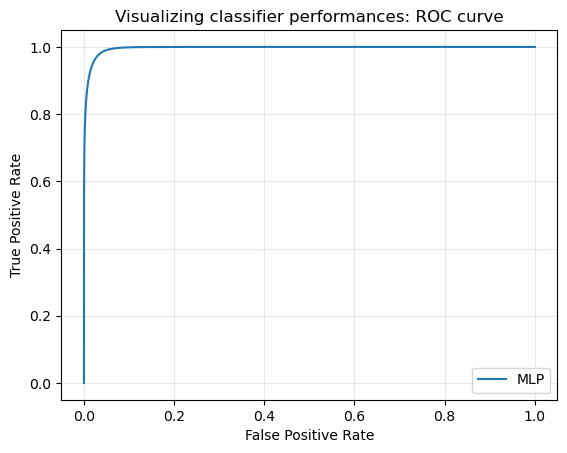

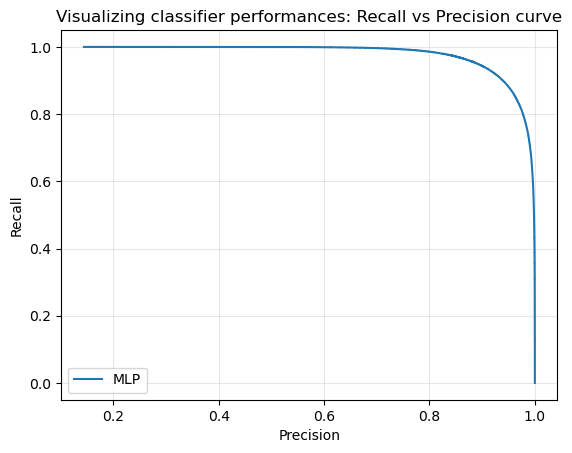

In [35]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [48]:
report_dict = classification_report(y_test, y_pred_mlp, output_dict=True)
accuracy = report_dict.pop('accuracy')
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(5)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.97752


In [49]:
df_report

,precision,recall,f1-score,support
0.0,0.98786,0.98585,0.98685,5134533.0
1.0,0.91705,0.92814,0.92256,865467.0
macro avg,0.95245,0.95699,0.95471,6000000.0
weighted avg,0.97765,0.97752,0.97758,6000000.0
